In [60]:
import pandas as pd

In [61]:
df = pd.read_csv('/content/StudentPerformance.csv')

In [62]:
df


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [63]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [64]:
df.head(2)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0


In [65]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [66]:
df.notnull().sum()

,0
Hours Studied,10000
Previous Scores,10000
Extracurricular Activities,10000
Sleep Hours,10000
Sample Question Papers Practiced,10000
Performance Index,10000


In [67]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

In [69]:
df['Extracurricular Activities'].value_counts()

,count
Extracurricular Activities,
No,5052
Yes,4948


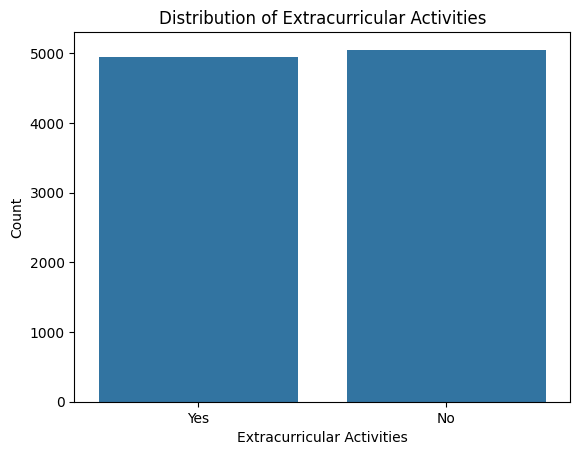

In [70]:
sns.countplot(data=df, x='Extracurricular Activities')
plt.title('Distribution of Extracurricular Activities')
plt.xlabel('Extracurricular Activities')
plt.ylabel('Count')
plt.show()

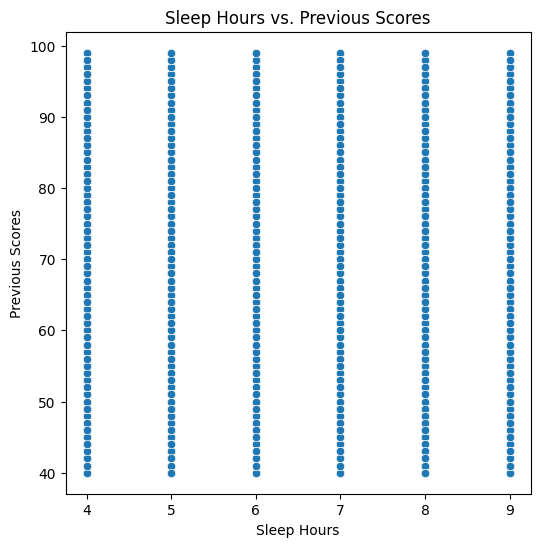

In [114]:
plt.figure(figsize=(6, 6))
sns.scatterplot(data=df, x='Sleep Hours', y='Previous Scores')
plt.title('Sleep Hours vs. Previous Scores')
plt.xlabel('Sleep Hours')
plt.ylabel('Previous Scores')
# plt.grid(True)
plt.show()

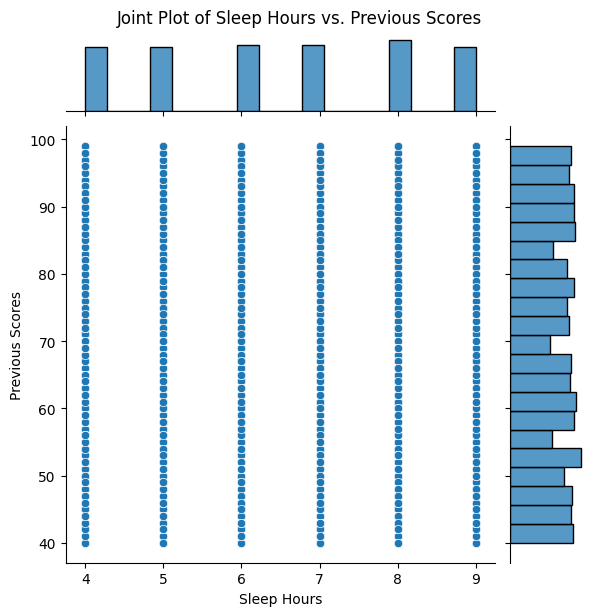

In [72]:
sns.jointplot(data=df, x='Sleep Hours', y='Previous Scores', kind='scatter')
plt.suptitle('Joint Plot of Sleep Hours vs. Previous Scores', y=1.02)
plt.show()

In [73]:
correlation = df['Sleep Hours'].corr(df['Previous Scores'])
print(f"Correlation between Sleep Hours and Previous Scores: {correlation:.2f}")

Correlation between Sleep Hours and Previous Scores: 0.01


In [74]:
df.corr(numeric_only=True)

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.012390,0.001245,0.017463,0.373730
Previous Scores,-0.012390,1.000000,0.005944,0.007888,0.915189
Sleep Hours,0.001245,0.005944,1.000000,0.003990,0.048106
Sample Question Papers Practiced,0.017463,0.007888,0.003990,1.000000,0.043268
Performance Index,0.373730,0.915189,0.048106,0.043268,1.000000


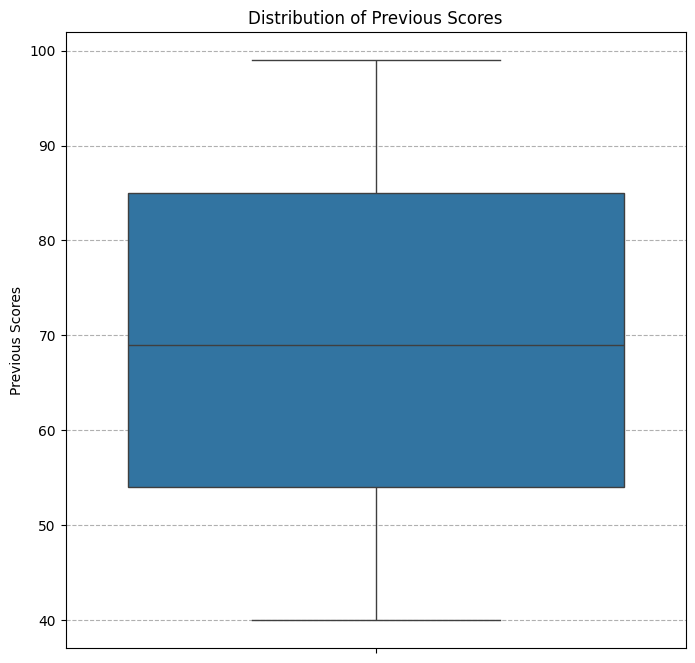

In [122]:
plt.figure(figsize=(8, 8))
sns.boxplot(y=df['Previous Scores'])
plt.title('Distribution of Previous Scores')
plt.ylabel('Previous Scores')
plt.grid(axis='y', linestyle='--', alpha=1)
plt.show()

In [109]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

In [77]:
le = LabelEncoder()
df['Extracurricular Activities']= le.fit_transform(df['Extracurricular Activities'])

In [78]:
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,1,4,2,23.0
9996,7,64,1,8,5,58.0
9997,6,83,1,8,5,74.0
9998,9,97,1,7,0,95.0


In [79]:
x = df.drop('Performance Index', axis=1)
y = df['Performance Index']

In [80]:
x

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,1,9,1
1,4,82,0,4,2
2,8,51,1,7,2
3,5,52,1,5,2
4,7,75,0,8,5
...,...,...,...,...,...
9995,1,49,1,4,2
9996,7,64,1,8,5
9997,6,83,1,8,5
9998,9,97,1,7,0


In [81]:
y

,Performance Index
0,91.0
1,65.0
2,45.0
3,36.0
4,66.0
...,...
9995,23.0
9996,58.0
9997,74.0
9998,95.0


In [82]:
x_train, x_test, y_train, y_test = train_test_split(x ,y, test_size=0.2, random_state=42)

In [83]:
x_train

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
9254,5,49,0,7,5
1561,2,48,1,7,6
1670,2,81,0,7,2
6087,2,46,0,6,1
6669,8,47,0,9,0
...,...,...,...,...,...
5734,8,50,1,6,6
5191,4,68,0,9,3
5390,9,48,0,7,6
860,1,47,0,9,0


In [84]:
x_test

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
6252,5,69,0,8,2
4684,2,46,1,4,8
1731,7,56,1,7,5
4742,6,42,1,8,5
4521,7,53,0,4,6
...,...,...,...,...,...
6412,2,70,0,7,3
8285,4,79,0,9,3
7853,2,40,1,7,2
1095,3,83,0,7,5


In [85]:
y_train

,Performance Index
9254,36.0
1561,25.0
1670,59.0
6087,22.0
6669,40.0
...,...
5734,48.0
5191,51.0
5390,44.0
860,20.0


In [86]:
lr_model = LinearRegression()
lr_model.fit(x_train, y_train)

LinearRegression()

In [87]:
x_train_pred = lr_model.predict(x_train)

In [88]:
x_train_pred

array([34.47064278, 25.69665091, 57.88131903, ..., 45.05542174,
       21.02145642, 22.57711635])

In [89]:
y_train

,Performance Index
9254,36.0
1561,25.0
1670,59.0
6087,22.0
6669,40.0
...,...
5734,48.0
5191,51.0
5390,44.0
860,20.0


In [90]:
print(mean_squared_error(y_train, x_train_pred))

4.169735849525007


In [91]:
x_test_pred = lr_model.predict(x_test)

In [92]:
print(mean_squared_error(y_test, x_test_pred))

4.082628398521853


In [93]:
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,1,4,2,23.0
9996,7,64,1,8,5,58.0
9997,6,83,1,8,5,74.0
9998,9,97,1,7,0,95.0


In [94]:
x

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,1,9,1
1,4,82,0,4,2
2,8,51,1,7,2
3,5,52,1,5,2
4,7,75,0,8,5
...,...,...,...,...,...
9995,1,49,1,4,2
9996,7,64,1,8,5
9997,6,83,1,8,5
9998,9,97,1,7,0


/tmp/ipython-input-1850307499.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_sleep_by_extracurricular, x='Extracurricular Activities', y='Sleep Hours', palette='viridis')


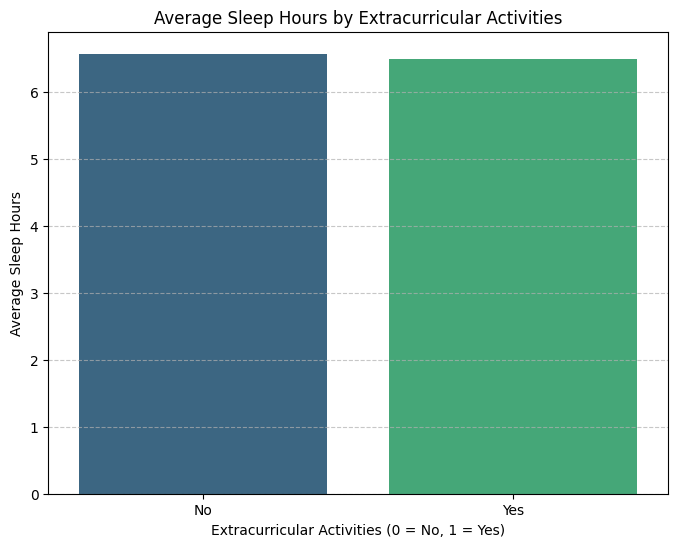

In [95]:
avg_sleep_by_extracurricular = df.groupby('Extracurricular Activities')['Sleep Hours'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(data=avg_sleep_by_extracurricular, x='Extracurricular Activities', y='Sleep Hours', palette='viridis')
plt.title('Average Sleep Hours by Extracurricular Activities')
plt.xlabel('Extracurricular Activities (0 = No, 1 = Yes)')
plt.ylabel('Average Sleep Hours')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [96]:
df1= df.drop('Extracurricular Activities', axis =1)

In [97]:
df1


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,9,1,91.0
1,4,82,4,2,65.0
2,8,51,7,2,45.0
3,5,52,5,2,36.0
4,7,75,8,5,66.0
...,...,...,...,...,...
9995,1,49,4,2,23.0
9996,7,64,8,5,58.0
9997,6,83,8,5,74.0
9998,9,97,7,0,95.0


In [98]:
x1 = df1.drop('Performance Index', axis=1)
y1 = df1['Performance Index']

In [99]:
x1_train, x1_test, y1_train, y1_test = train_test_split(x1 ,y1, test_size=0.3, random_state=54)

In [100]:
r_model = LinearRegression()
lr_model.fit(x1_train, y1_train)

LinearRegression()

In [101]:
x1_train_pred = lr_model.predict(x1_train)


In [102]:
x1_train_pred

array([65.75746466, 54.30825589, 47.79413774, ..., 53.46443866,
       62.12404428, 32.02438468])

In [103]:
y1_train

,Performance Index
3573,67.0
8620,52.0
9165,49.0
6699,40.0
5377,48.0
...,...
7480,34.0
5143,44.0
898,50.0
7493,62.0


In [104]:
print(mean_squared_error(y1_train, x1_train_pred))

4.25659985172628


In [105]:
x1_test_pred = lr_model.predict(x1_test)

In [106]:
print(mean_squared_error(y1_test, x1_test_pred))

4.223977144229445


In [110]:
print(mean_absolute_error(y_test, x_test_pred))

1.6111213463123044
